# Pipeline

This file details how the Movie dataset can be used. 

Set up logging

In [ ]:
import logging
#set up logging
logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='pipeline.log'
)
logger = logging.getLogger(__name__)

First load all of the data into a DuckDB database

In [ ]:
#importing 
import duckdb
import pandas as pd

#try-except blocks for error handling
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    con.execute("CREATE TABLE IF NOT EXISTS mov AS SELECT * FROM read_parquet('data/mov.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS netmov AS SELECT * FROM read_parquet('data/net_mov.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS rat AS SELECT * FROM read_parquet('data/rat.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS users AS SELECT * FROM read_parquet('data/users.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS history AS SELECT * FROM read_parquet('data/watch_history.parquet');")

    con.close()
    logger.info("Loaded data into a Duckdb database")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


Now moving on to querying and model building

Finding all ratings for movies that do appear on Netflix. This will be used as training data for the model. The query will return all columns from the users data table, the rating, all columns from the movie data table, and three columns from the users watch history.

In [ ]:
#SQL Query
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    #creating the database that the model will be trained upon
    net_df = con.execute("""
        SELECT 
            u.*, 
            r.rating, 
            m.*,
            h.num_movies_watched, h.total_minutes_watched
            FROM users u
        INNER JOIN history h ON h.userId = u.userId
        INNER JOIN rat r on r.userID = u.userId
        INNER JOIN mov m ON m.movieId = r.movieId
        LEFT JOIN netmov n ON n.movieId = m.movieId
        WHERE n.movieId IS NOT NULL;
    """).fetchdf()
    logger.info("Netflix Data extraction")
    #ensure that the connection is closed
    con.close()

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")
#peak
net_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,8315,Laborer,31,41700.59,4.5,2858,American Beauty,1999,0,0,...,0,0,0,1,0,0,0,0,202,18382
1,8315,Laborer,31,41700.59,2.0,2916,Total Recall,1990,0,1,...,0,0,0,0,1,1,0,0,202,18382
2,8315,Laborer,31,41700.59,4.5,4232,Spy Kids,2001,0,1,...,0,0,0,0,0,0,0,0,202,18382
3,8315,Laborer,31,41700.59,3.0,6863,School of Rock,2003,0,0,...,0,1,0,0,0,0,0,0,202,18382
4,8315,Laborer,31,41700.59,5.0,7293,50 First Dates,2004,0,0,...,0,0,0,1,0,0,0,0,202,18382


Finding all ratings for movies that do not appear on Netflix. Limiting this to the first 500,000 reviews for memory reasons. The query will return all columns from the users data table, the rating, all columns from the movie data table, and three columns from the users watch history.

In [ ]:
#SQL Query
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    #creating the database that the model will be tested upon
    movs_df = con.execute("""
        SELECT 
            u.*, 
            r.rating, 
            m.*,
            h.num_movies_watched, h.total_minutes_watched
            FROM users u
        INNER JOIN history h ON h.userId = u.userId
        INNER JOIN rat r on r.userID = u.userId
        INNER JOIN mov m ON m.movieId = r.movieId
        LEFT JOIN netmov n ON n.movieId = m.movieId
        WHERE n.movieId IS NULL
        LIMIT 500000;
    """).fetchdf()
    logger.info("Non Netflix Data extraction")
    #close
    con.close()
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")
#peak
movs_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,1611,Retail sales associate,28,54158.85,3.5,82461,Tron: Legacy,2010,0,1,...,1,0,0,0,1,0,0,0,179,15752
1,1611,Retail sales associate,28,54158.85,3.0,84772,Paul,2011,0,0,...,0,0,0,0,1,0,0,0,179,15752
2,1611,Retail sales associate,28,54158.85,3.0,85414,Source Code,2011,0,1,...,0,0,1,0,1,1,0,0,179,15752
3,1611,Retail sales associate,28,54158.85,3.0,87306,Super 8,2011,0,0,...,1,0,1,0,1,1,0,0,179,15752
4,1611,Retail sales associate,28,54158.85,3.0,87485,Bad Teacher,2011,0,0,...,0,0,0,0,0,0,0,0,179,15752


Test to ensure that there is no overlap with movies

In [ ]:
#test
try:    
    #see if the merge returns anything
    df_merged = movs_df.merge(net_df, on='movieId', how='inner')
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")
df_merged.shape

(0, 59)

Now Cleaning the data to ensure it is ready for the model. 

In [ ]:
#peak
movs_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,1611,Retail sales associate,28,54158.85,3.5,82461,Tron: Legacy,2010,0,1,...,1,0,0,0,1,0,0,0,179,15752
1,1611,Retail sales associate,28,54158.85,3.0,84772,Paul,2011,0,0,...,0,0,0,0,1,0,0,0,179,15752
2,1611,Retail sales associate,28,54158.85,3.0,85414,Source Code,2011,0,1,...,0,0,1,0,1,1,0,0,179,15752
3,1611,Retail sales associate,28,54158.85,3.0,87306,Super 8,2011,0,0,...,1,0,1,0,1,1,0,0,179,15752
4,1611,Retail sales associate,28,54158.85,3.0,87485,Bad Teacher,2011,0,0,...,0,0,0,0,0,0,0,0,179,15752


In [177]:
try:
    #splitting into input and prediction data
    y = movs_df["rating"]
    X = movs_df.drop("rating", axis=1)

    #getting rid of large categorical columns
    X.drop(["title", "year"], axis=1, inplace=True)

    #one hot encoding the job column
    #one hot encode
    dummies = pd.get_dummies(X["job"], prefix="job")
    #make it numerical
    dummies = dummies.astype(int)
    #join the columns
    X = X.join(dummies)
    #drop the old columns
    X.drop(columns=["job"], inplace=True)

    #finally, drop the user and movie ID columns

    X.drop(["movieId", "userId"], axis = 1, inplace=True)
    logger.info("Preparing the data for model training")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


In [178]:
X.head()

,age,salary,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,job_Maintenance technician,job_Marketing manager,job_Nursing assistant,job_Office clerk,job_Registered nurse,job_Retail sales associate,job_Sales manager,job_Server,job_Truck driver,job_Web developer
0,28,54158.85,0,1,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,28,54158.85,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,28,54158.85,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,28,54158.85,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,28,54158.85,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [179]:
y.head()

0    3.5
1    3.0
2    3.0
3    3.0
4    3.0
Name: rating, dtype: float64

#### Model Work

For this project, a Random Forest regressor will be used to predict the ratings of movies that do not appear on Netflix yet. A Random Forest model was chosen as it is an ensemble model that combines many smaller decision trees (which will hopefully lead to more robust/less variable predictions). Additionally it was chosen as it is a very easy model to visualize/comprehend and it can work with the large amount of data being processed in this project. Finally, a regressor was chosen because the ratings (target variable) are semi discrete (e.g. 0.5, 1.0), so a regressor is equipped to handle these values. 

In [185]:
# Importing packages
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

First the data is split up and the pipeline is built. 

In [186]:
try:
    #further split the data to obtain a new training and testing set
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)


    #create a pipeline
    pipeline_regressor = Pipeline([
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    logger.info("Building the random forest model")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


Then the optimal hyperparameters for this model are found using GridSearchCV. 

In [ ]:
try:

    #create a parameter table
    parameter_grid_regressor = {"regressor__n_estimators": [20, 100], "regressor__max_depth": [5, 10]}
    #find best parameter
    grid_search_ridge = GridSearchCV(pipeline_regressor, parameter_grid_regressor, cv=3)
    #fit
    grid_search_ridge.fit(X_train_rf, y_train_rf.values.ravel())
    print(grid_search_ridge.best_params_)
    logger.info("Finding the optimal hyperparameters")
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


{'regressor__max_depth': 10, 'regressor__n_estimators': 100}


The optimal parameters are then used to train the model

In [188]:
try:
    #grab all the optimal parameters
    best_estimators = grid_search_ridge.best_params_["regressor__n_estimators"]
    best_depth = grid_search_ridge.best_params_["regressor__max_depth"]

    #create a new pipeline that includes the optimized parameters
    pipeline_regressor_improved = Pipeline([
        ('regressor', RandomForestRegressor(n_estimators=best_estimators, max_depth=best_depth, max_features="sqrt", random_state=42))
    ])

    #fit the pipeline again with the optimized parameters
    logger.info("Refitting the model with the ideal hyperparameters")
    pip_improved = pipeline_regressor_improved.fit(X_train_rf, y_train_rf.values.ravel())

    #make predictions
    y_pred = pipeline_regressor_improved.predict(X_test_rf)

    logger.info("Predicting using the ideal hyperparameters")
    #score
    r2 = r2_score(y_test_rf, y_pred) # Predict on the test set
    print("R2 is equal to:", r2)
    #score
    MSE = mean_squared_error(y_test_rf, y_pred)
    print("MSE is equal to: ", MSE)
    
    logger.info("Getting Metrics")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


R2 is equal to: 0.12034010229147074
MSE is equal to:  1.0125070149224455


Note for this model. The R-squared value is likely very low due to synthetic data. For an actual implementation of this model, real user data would be preferred so that the model can make better predictions. 

Time to create a visualization

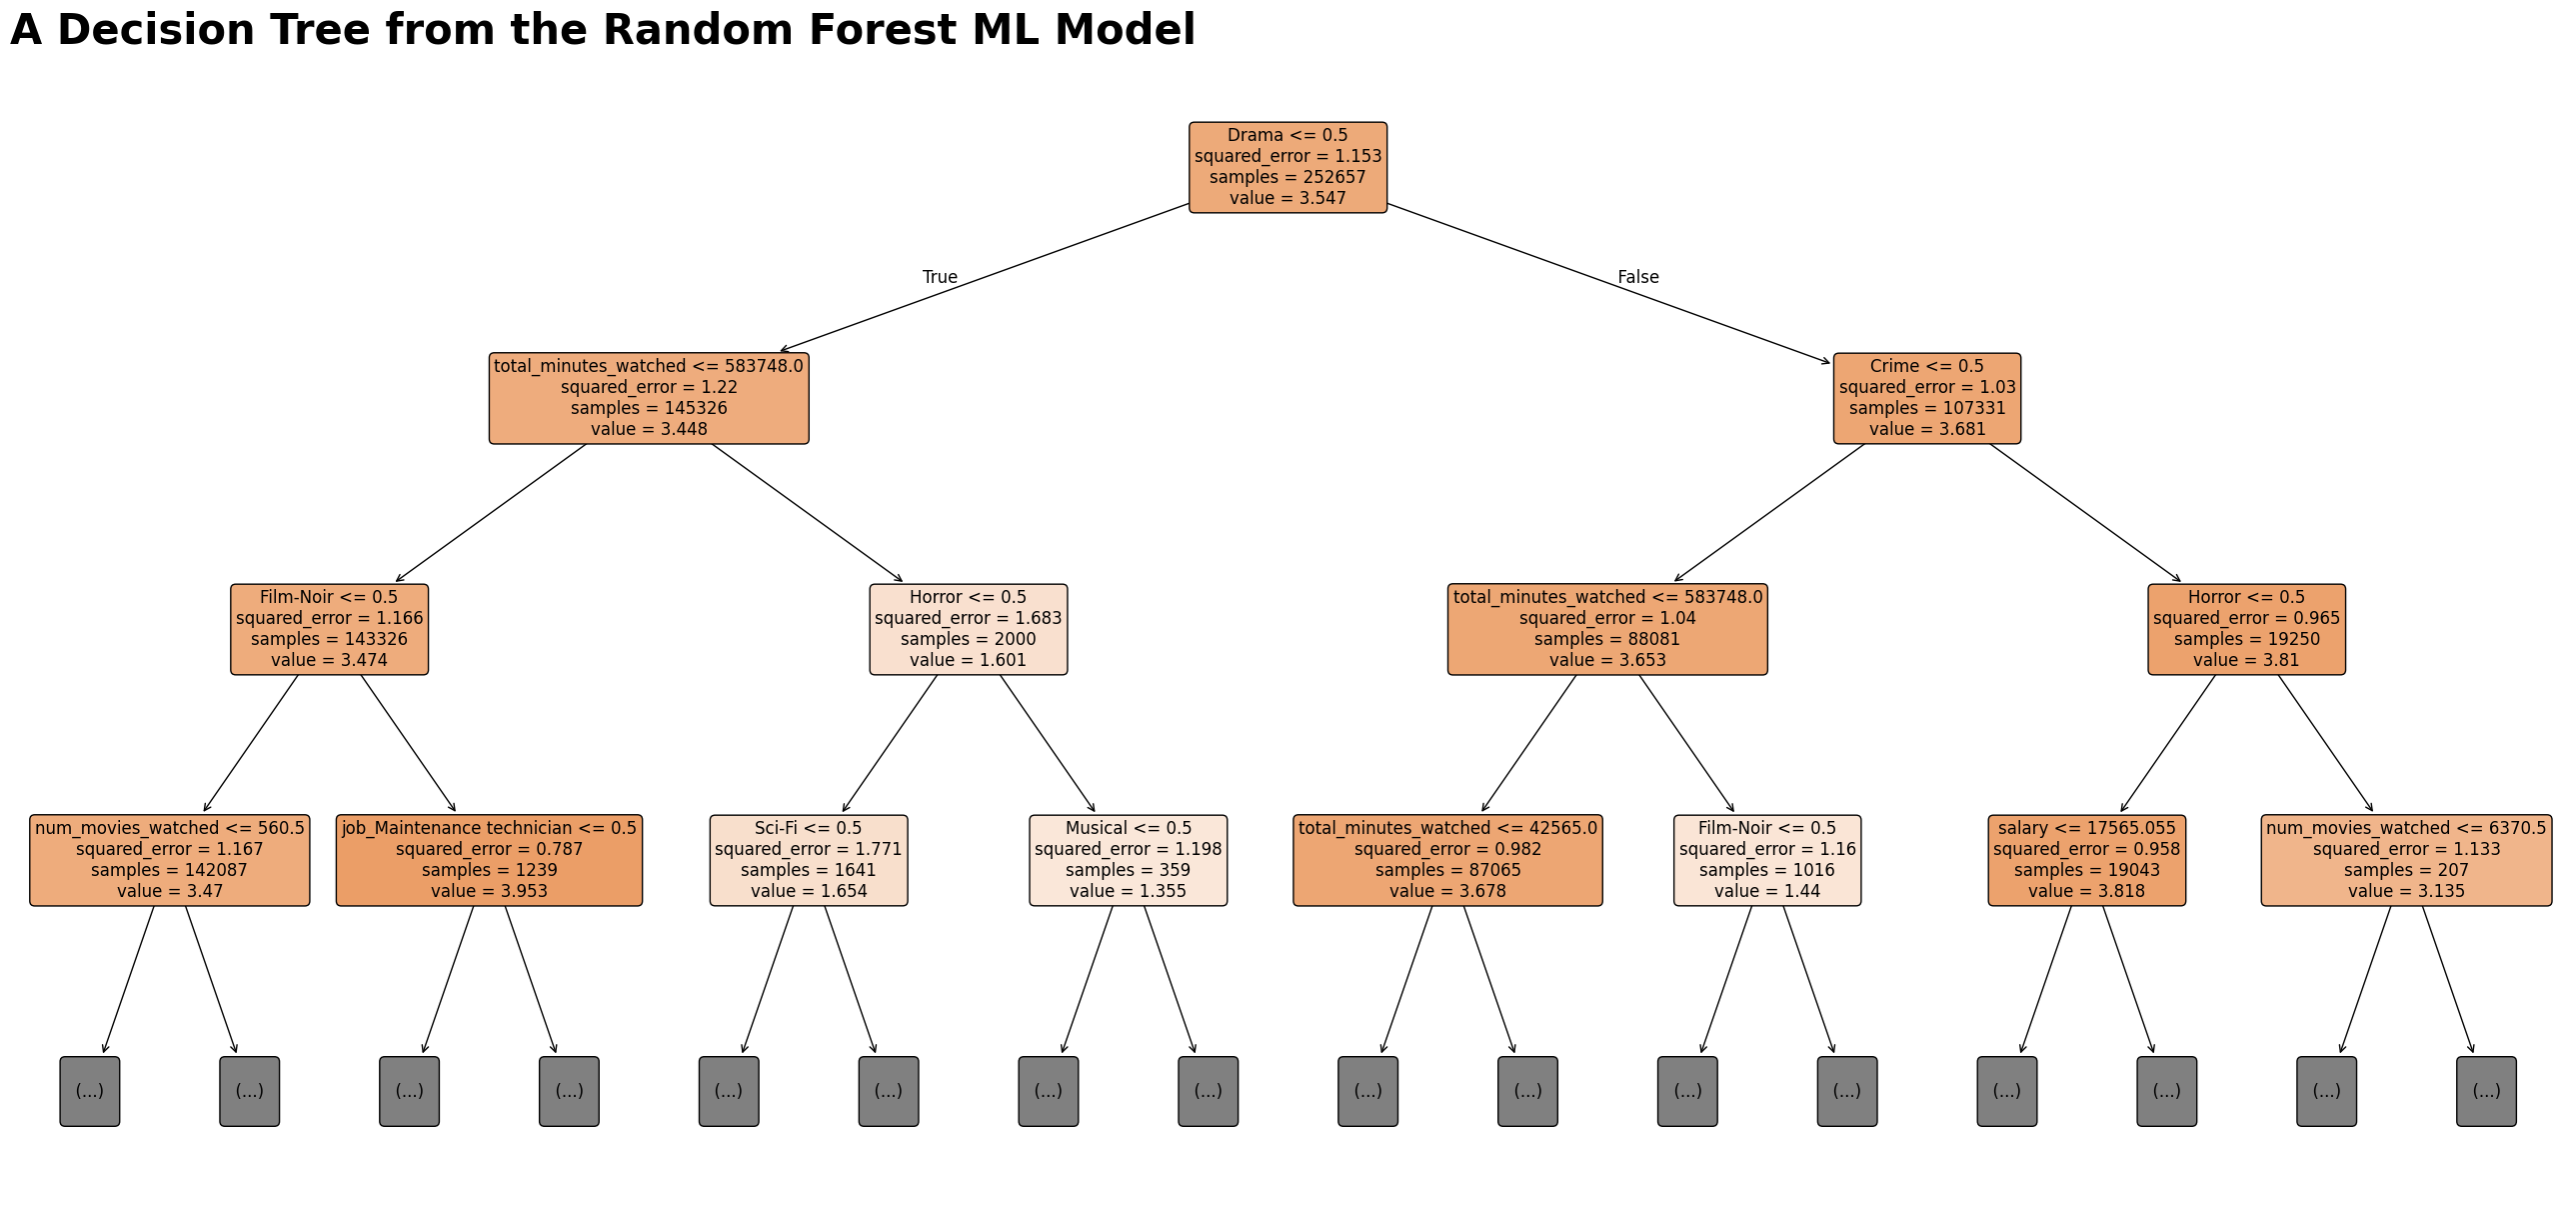

In [ ]:
try:
        
    #visualize one of the trees
    rf = pipeline_regressor_improved.named_steps["regressor"]
    tree_plot = rf.estimators_[0]
    cols = X_train_rf.columns
    #using matplotlib
    plt.figure(figsize=(33, 15))
    plot_tree(tree_plot, feature_names=cols, filled=True, rounded=True, fontsize=12, max_depth = 3)
    plt.title("A Decision Tree from the Random Forest ML Model", loc="left", fontsize = 30, fontweight = "bold")
    plt.savefig("tree.png")
    plt.show()
    logger.info("Creating and saving an image")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

This visualization showcases a singular decision tree from the random forest model implemented above. A random forest model incorporates many individual decision trees to make its predictions. A decision tree is a very easily visualized model as it shows the logical decision breaks that lead to the decision of the model. Since it is easily visualized, users/decision makers are able to more easily comprehend how the model that they are using is working. I choose this visualization for this reason, so that the model can be more easily interpretted by people. Additionally, I ensured that the title of the visualization was off-center so as to draw more attention to it. 


### Further usage of the dataset

The dataset can also be used to find average movie ratings for different subgroups of people. Below is a SQL query that finds the average rating and number of ratings for combinations of movie genres, age ranges, and occupation. 

In [193]:
try:
    #connect to database
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    # Multi-dimensional aggregation query
    query = """
    SELECT
        u.job,
        -- Get all genres dynamically by one-hot columns
        CASE
            WHEN m.Comedy = 1 THEN 'Comedy'
            WHEN m.Drama = 1 THEN 'Drama'
            WHEN m.Action = 1 THEN 'Action'
            WHEN m.Adventure = 1 THEN 'Adventure'
            ELSE 'Other'
        END AS genre,
        CASE
            WHEN u.age < 30 THEN '<30'
            WHEN u.age < 50 THEN '30-49'
            ELSE '50+'
        END AS age_group,
        AVG(r.rating) AS avg_rating,
        COUNT(*) AS num_ratings
    FROM rat r
    JOIN users u ON r.userId = u.userId
    JOIN mov m ON r.movieId = m.movieId
    JOIN watch_history w ON u.userId = w.userId
    WHERE w.total_minutes_watched > 500
    GROUP BY u.job, genre, age_group
    ORDER BY u.job, genre, age_group
    """
    # Execute query
    multi_dim_results = con.execute(query).fetchdf()

    # Print the first 20 rows of the multi-dimensional aggregation
    print("Average ratings by Job × Genre × Age Group (for users with >500 min watched):\n")
    #printing just the head
    print(multi_dim_results.head(20))
    logger.info("Testing a query")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

Average ratings by Job × Genre × Age Group (for users with >500 min watched):

                         job      genre age_group  avg_rating  num_ratings
0                 Accountant     Action       50+    3.447561       279326
1                 Accountant  Adventure       50+    3.596552        47151
2                 Accountant     Comedy       50+    3.434071       572459
3                 Accountant      Drama       50+    3.686488       555337
4                 Accountant      Other       50+    3.542462       163852
5           Accounting clerk     Action     30-49    3.454031       282035
6           Accounting clerk  Adventure     30-49    3.611457        47911
7           Accounting clerk     Comedy     30-49    3.439288       560869
8           Accounting clerk      Drama     30-49    3.702389       554519
9           Accounting clerk      Other     30-49    3.547449       165842
10  Administrative assistant     Action     30-49    3.455937       283832
11  Administrative as

This could also be easily shifted to find the exact same stats for netflix movies. This is shown below. 

In [194]:
try:
    #connect to database
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    # Multi-dimensional aggregation query
    query = """
    SELECT
        u.job,
        -- Get all genres dynamically by one-hot columns
        CASE
            WHEN m.Comedy = 1 THEN 'Comedy'
            WHEN m.Drama = 1 THEN 'Drama'
            WHEN m.Action = 1 THEN 'Action'
            WHEN m.Adventure = 1 THEN 'Adventure'
            ELSE 'Other'
        END AS genre,
        CASE
            WHEN u.age < 30 THEN '<30'
            WHEN u.age < 50 THEN '30-49'
            ELSE '50+'
        END AS age_group,
        AVG(r.rating) AS avg_rating,
        COUNT(*) AS num_ratings
    FROM rat r
    JOIN users u ON r.userId = u.userId
    JOIN netmov m ON r.movieId = m.movieId
    JOIN watch_history w ON u.userId = w.userId
    WHERE w.total_minutes_watched > 500
    GROUP BY u.job, genre, age_group
    ORDER BY u.job, genre, age_group
    """
    # Execute query
    multi_dim_results = con.execute(query).fetchdf()

    # Print the first 20 rows of the multi-dimensional aggregation
    print("Average ratings by Job × Genre × Age Group (for users with >500 min watched):\n")
    #printing just the head
    print(multi_dim_results.head(20))
    logger.info("Testing a query")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

Average ratings by Job × Genre × Age Group (for users with >500 min watched):

                         job      genre age_group  avg_rating  num_ratings
0                 Accountant     Action       50+    3.407677        42622
1                 Accountant  Adventure       50+    3.292008         1589
2                 Accountant     Comedy       50+    3.409642        79002
3                 Accountant      Drama       50+    3.726066        94143
4                 Accountant      Other       50+    3.458280        23646
5           Accounting clerk     Action     30-49    3.419643        43618
6           Accounting clerk  Adventure     30-49    3.307092         1537
7           Accounting clerk     Comedy     30-49    3.416941        78234
8           Accounting clerk      Drama     30-49    3.742438        94447
9           Accounting clerk      Other     30-49    3.490085        23197
10  Administrative assistant     Action     30-49    3.436246        43174
11  Administrative as